In [2]:
# Importacio de librerias necesarias
import os
import re
import pandas as pd

In [36]:
# Definir ruta donde se encuentra el archivo raw
ruta = os.path.join('..', 'data', 'raw', 'Chat_Whatsapp.txt')

# Abrir el archivo y leer solo las primeras 5 líneas para inspeccionar
with open(ruta, "r", encoding="utf-8") as file:
    content = file.read()

content

'5/5/2024, 11:04\u202fa.\u202fm. - \u200ePablo creó el grupo "PRIMARIA 6to C 🗣 🎒📚".\n5/5/2024, 11:04\u202fa.\u202fm. - Se te añadió al grupo.\n24/5/2024, 11:27\u202fa.\u202fm. - Victor: Cambié de cel y se me borraron todos los datos de whatsapp gg\n24/5/2024, 11:27\u202fa.\u202fm. - Victor: \u200eSTK-20240524-WA0002.webp (archivo adjunto)\n24/5/2024, 11:31\u202fa.\u202fm. - Efrén Camargo: We que chilo alv\n24/5/2024, 11:31\u202fa.\u202fm. - Victor: Y si\n24/5/2024, 11:31\u202fa.\u202fm. - Efrén Camargo: La quisieras\n24/5/2024, 11:31\u202fa.\u202fm. - Efrén Camargo: Para salir?\n24/5/2024, 11:31\u202fa.\u202fm. - Victor: Cómo?\n24/5/2024, 11:31\u202fa.\u202fm. - Victor: De que literalmente solo para salir? Jajaja\n24/5/2024, 11:32\u202fa.\u202fm. - Efrén Camargo: Simon\n24/5/2024, 11:39\u202fa.\u202fm. - Pablo: Pinchi Andree no contaste mi mensaje\n24/5/2024, 11:39\u202fa.\u202fm. - Pablo: \u200eSTK-20240524-WA0006.webp (archivo adjunto)\n24/5/2024, 11:39\u202fa.\u202fm. - Victor: Perd

La estructura de todas las filas en el archivo .txt es la siguiente : 
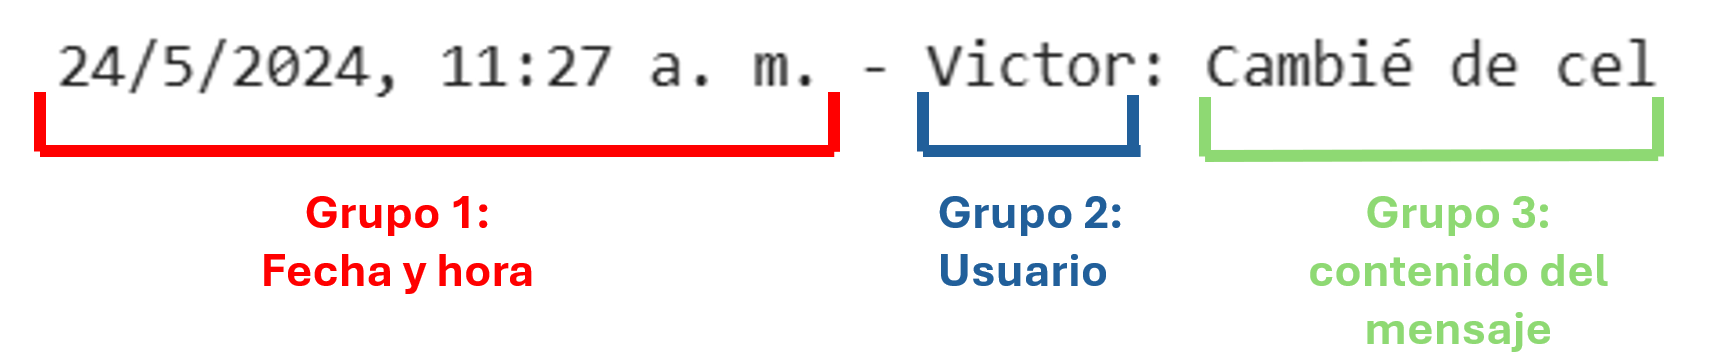
Para poder acceder a cada una de las filas, haremos uso de la expresiones regulares y de la libreria re. Primeramente, definiremos nuestra expresion regular para acceder a cada una de las filas.

In [ ]:
# Definir el patron de tres grupos presente en cada linea
patron = (r"^(\d{1,2}/\d{1,2}/\d{4},\s\d{1,2}:\d{2}\s[a|p]\.\sm\.)\s-\s([^:]+):\s(.*)$")

## Explicacion de la expresion regular

__Grupo 1 (fecha y hora)__: \d{1,2}/\d{1,2}/\d{4},\s\d{1,2}:\d{2}\s[a|p]\.\sm\.

* \d{1,2}/: busca cualquier digito numerico del 0 al 9 de dos digitos y termina por buscar la diagonal literal de la fecha.
* \d{4}/: busca cualquier digito numerico del 0 al 9 de 4 digitos (el año) y termina por buscar la diagonal literal de la fecha.
* ,\s : busca despues de la fecha una coma y un espacio en blanco. 
* \d{1,2}: busca cualquier digito numerico del 0 al 9 de dos digitos y termina por buscar los dos puntos. 
* \d{2}\ busca cualquier digito numero del 0 al 9 de dos digitos (la hora)
* \s[a|p] : busca un espacio en blanco y despues una letra que sea "a" o que sea "p", 
* \.\sm\. : busca un punto, un espacio, una m (recorda por am o pm) y un punto. 
\s-\s : busca un espacio, un guion y un espacio. 

__Grupo 2 (Usuario)__ : ([^:]+)
* [^:]+: : buscará cualquier carácter que no sean dos puntos (el nombre del usuario) y se detendrá al encontrar los dos puntos. Al final, buscará dos puntos. 

__Grupo 3 (contenido del mensaje__):
* \s(.*)$ :se saltará un espacio y después buscará 0 o más caracteres (números, letras, simbolos, etc.)

In [ ]:
# Prueba para probar la expresion regular utilizando la libreria re
import re

# Tomaremos una de las lineas que viene en el archivo crudo .txt
linea_prueba = ('24/5/2024, 11:27 a. m. - Victor: Cambié de cel y se me borraron todos los datos de whatsapp gg')

# Uso del metodo re.match() para encontrar verificar coincidencias entre la expresion regular (patron) y la linea de prueba
coincidencia = re.match(patron, linea_prueba)
if coincidencia:
    print('Hay coincidencia')
else:
    print('No hay coincidencia')

# Una vez encontrada la coincidencia, usaremos el metodo.groups() para crear grupos de captura. Los grupos de captura estan definidos por los parentesis que colocamos en nuestra expresion regular.

fecha_hora, usuario, mensaje = coincidencia.groups()
print(f'\nFecha y hora: {fecha_hora}')
print(f'Usuario: {usuario}')
print(f'Mensaje: {mensaje}')


Hay coincidencia

Fecha y hora: 24/5/2024, 11:27 a. m.
Usuario: Victor
Mensaje: Cambié de cel y se me borraron todos los datos de whatsapp gg


Ya que nuestra expresion sirvio para extraer el mensaje, ahora vamos a iterar sobre todo el archivo con la finalidad de obtener distintas fechas, usuarios, y contenido. 

In [13]:
# Definir ruta donde se encuentra el archivo raw
ruta = os.path.join('..', 'data', 'raw', 'Chat_Whatsapp.txt')

# Definir el patron de tres grupos presente en cada linea
patron = (r"^(\d{1,2}/\d{1,2}/\d{4},\s\d{1,2}:\d{2}\s[a|p]\.\sm\.)\s-\s([^:]+):\s(.*)$")

# Lista vacia donde se acumulará cada mensaje enviado por cada usuario
mensajes = []

mensaje_actual = None # Nos servira para iterar sobre cada mensaje y ayudara para agregar cada nuevo mensaje a la lista de 'mensajes'

# Abrir el archivo y leer solo las primeras 5 líneas para inspeccionar
with open(ruta, "r", encoding="utf-8") as file:
    # Iteracion sobre cada linea o fila del archivo
    for fila in file:

        coincidencia = re.match(patron, fila)
            
        # Si coincidencia es True, significa que hay match entre patron y y la fila actual 
        if coincidencia:

            # A partir de la segunda iteracion, mensaje_actual sera True y lo agregaremos a nuestra lista de mensajes
            if mensaje_actual:
                mensajes.append(mensaje_actual)

            # Extraeremos la fecha y hora, el usuario y el mensaje de la linea actual
            fecha_hora, usuario, contenido = coincidencia.groups() 
            mensaje_actual = {
                'timestamp_raw': fecha_hora.strip(),
                'usuario_original': usuario.strip(),
                'contenido' : contenido.strip(),}
        # Si coincidencia es False, significa que estamos iterando en una nueva fila que no tiene fecha, por lo que es un mensaje con un salto de linea
        else:
            if mensaje_actual:
                # Agregaremos el salto del linea al mensaje que tenemos en la iteracion actual.
                mensaje_actual['contenido'] += ' ' + fila.strip() 

 # Cuando salgamos del bucle, debemos de a;adir el ultimo mensaje con la siguiente iteracion:
if mensaje_actual:
    mensajes.append(mensaje_actual)


# Confirmar la longitud de la lista de diccionarios 'mensajes'
print(len(mensajes))

84591


[{'timestamp_raw': '24/5/2024, 11:27\u202fa.\u202fm.',
  'usuario_original': 'Victor',
  'contenido': 'Cambié de cel y se me borraron todos los datos de whatsapp gg'},
 {'timestamp_raw': '24/5/2024, 11:27\u202fa.\u202fm.',
  'usuario_original': 'Victor',
  'contenido': '\u200eSTK-20240524-WA0002.webp (archivo adjunto)'},
 {'timestamp_raw': '24/5/2024, 11:31\u202fa.\u202fm.',
  'usuario_original': 'Efrén Camargo',
  'contenido': 'We que chilo alv'},
 {'timestamp_raw': '24/5/2024, 11:31\u202fa.\u202fm.',
  'usuario_original': 'Victor',
  'contenido': 'Y si'},
 {'timestamp_raw': '24/5/2024, 11:31\u202fa.\u202fm.',
  'usuario_original': 'Efrén Camargo',
  'contenido': 'La quisieras'},
 {'timestamp_raw': '24/5/2024, 11:31\u202fa.\u202fm.',
  'usuario_original': 'Efrén Camargo',
  'contenido': 'Para salir?'},
 {'timestamp_raw': '24/5/2024, 11:31\u202fa.\u202fm.',
  'usuario_original': 'Victor',
  'contenido': 'Cómo?'},
 {'timestamp_raw': '24/5/2024, 11:31\u202fa.\u202fm.',
  'usuario_origina

La ingesta de datos se ha ralizado con éxito. Ahora, pasaremos esta lista de diccionarios a un dataframe de pandas el cual será tratado en el notebook "2. Limpiteza y Transformación de datos (tidy generación de tidy data)

In [20]:
# Convertir lista de diccionarios a dataframe
df_raw = pd.DataFrame(mensajes)

# Definir ruta donde se guardara el archivo
ruta = os.path.join('..', 'data', 'interim', 'df_raw.csv') # Esta carpeta sirve para guardar datos 'intermedios', de acuerdo a CCDS

# Exportar el DF en archivo CSV
df_raw.to_csv(ruta, encoding="utf-8-sig")
